Used: https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world

Figure 3: Circuit for Swap test: https://arxiv.org/pdf/2003.09187

For returning data: Qiskit provides 2 ways
- you can obtain a probability distribution for a set of qubits you choose to measure
- or you can obtain the expectation value of an observable

In our case, we wanna get the Fidelity.
$$
\text{Fidelity} = F
= \left|\langle \psi \mid \phi \rangle\right|^2
= 2P(0) - 1
$$

$$
\text{Expectation value} = \langle Z \rangle
= P(0) - P(1)
= 2P(0) - 1
= F
$$

So we wanna measure the q0 and get the expectation value, which is our fidelity.

Running on the simulator for now, so using FakeBelemV2 for now 

## Simplest setup: 2 train points, 1 test points, 1 dimension:

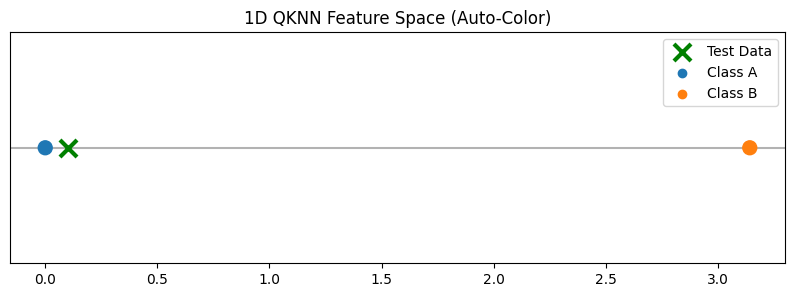

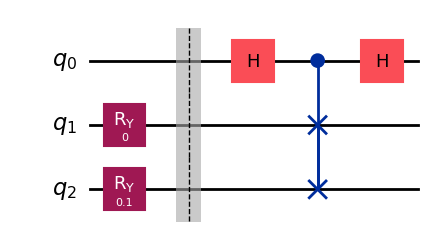

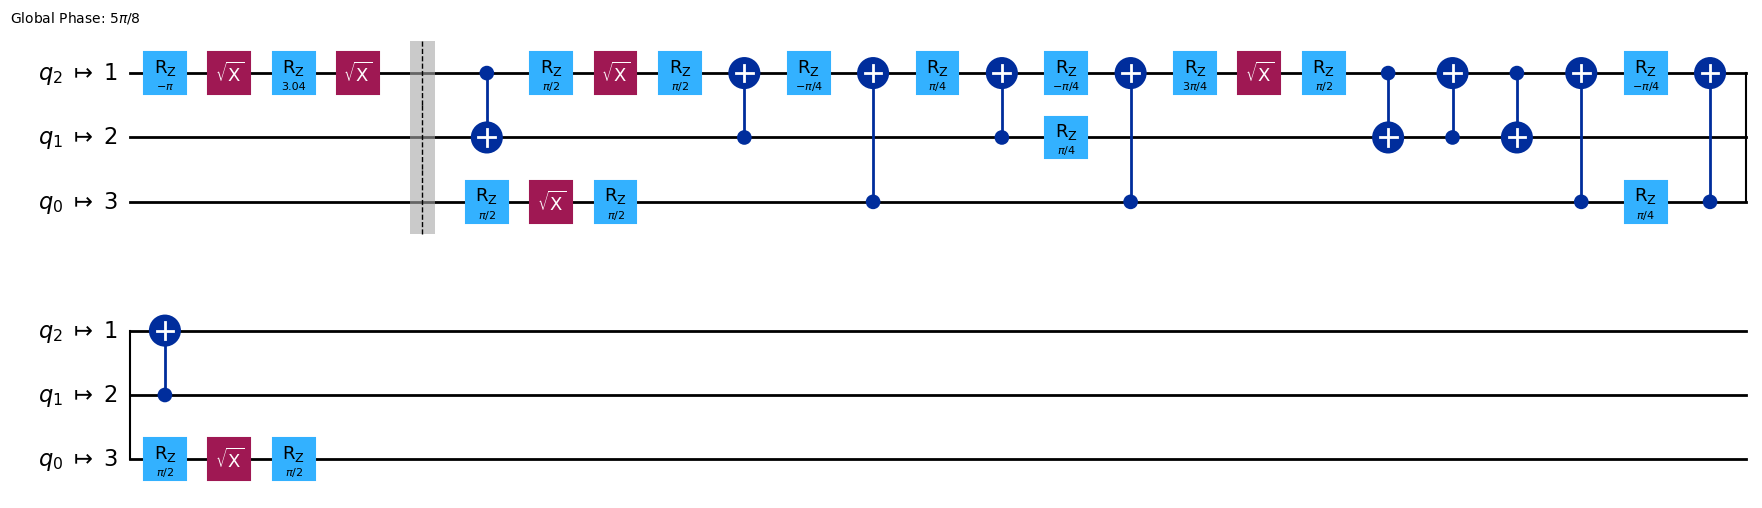

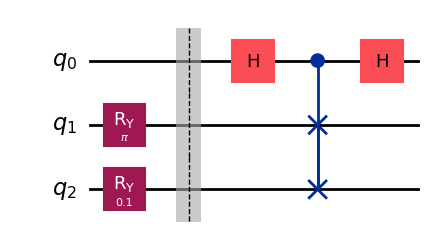

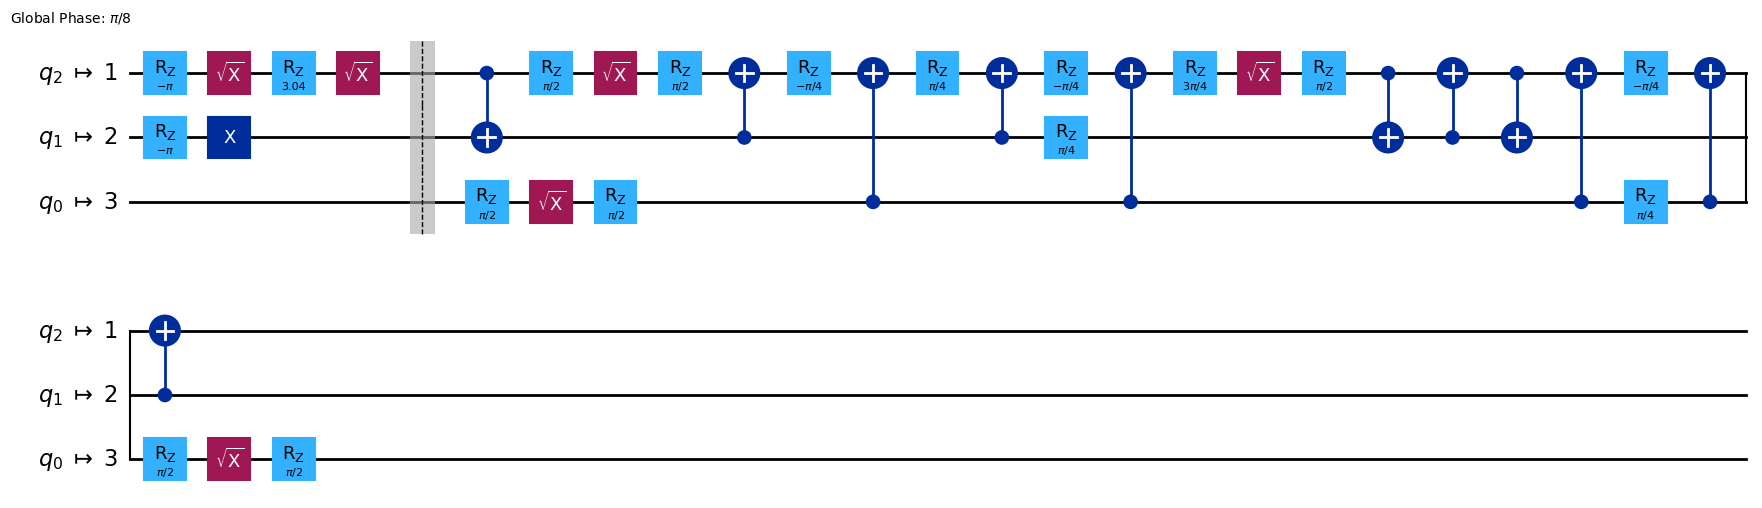

Fidelity Train 1 (Pi): 0.9972
Fidelity Train 2 (0):  0.0056
Prediction: Class A


In [60]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeBelemV2
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from collections import Counter

def visualize_1d(train_data, train_labels, test_data):
    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {label: cm(i) for i, label in enumerate(unique_labels)}
    
    plt.figure(figsize=(10, 3))
    plt.axhline(0, color='black', alpha=0.3)
    
    train_x = [pt[0] for pt in train_data]
    test_x = [pt[0] for pt in test_data]
    
    plt.scatter(train_x, np.zeros_like(train_x), 
                c=[color_map[l] for l in train_labels], s=100, zorder=2)
    
    plt.scatter(test_x, np.zeros_like(test_x), 
                c='green', marker='x', s=150, linewidths=3, label='Test Data', zorder=3)
    
    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label) 
    
    plt.title("1D QKNN Feature Space (Auto-Color)")
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.legend()
    plt.show()

def compute_fidelity_1d(train_val, test_val):
    qc = QuantumCircuit(3) # 1 for ancilla, 1 for 1 dimension train data, 1 for 1 dimension test data
    
    # 1. Encoding
    qc.ry(train_val, 1)
    qc.ry(test_val, 2)
    qc.barrier()
    
    # 2. SWAP Test
    qc.h(0)
    qc.cswap(0, 1, 2)
    qc.h(0)

    display(qc.draw("mpl"))

    isa = pm.run(qc)
    display(isa.draw("mpl"))
    obs = observable.apply_layout(isa.layout)
    estimator = Estimator(backend)
    job = estimator.run([(isa, obs)], precision=0.01)
    result = job.result()

    return result[0].data.evs

train_points = [0, np.pi]
train_labels = ['Class A', 'Class B']
test_point = 0.1

# Making it more complicated so it can be reused later
visualize_1d([np.array([x]) for x in train_points], train_labels, [np.array([test_point])])

backend = FakeBelemV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
observable = SparsePauliOp("IIZ") # Measure q0

fid1 = compute_fidelity_1d(train_points[0], test_point)
fid2 = compute_fidelity_1d(train_points[1], test_point)

print(f"Fidelity Train 1 (Pi): {fid1:.4f}")
print(f"Fidelity Train 2 (0):  {fid2:.4f}")

label = train_labels[0] if fid1 > fid2 else train_lables[1]
print(f"Prediction: {label}")

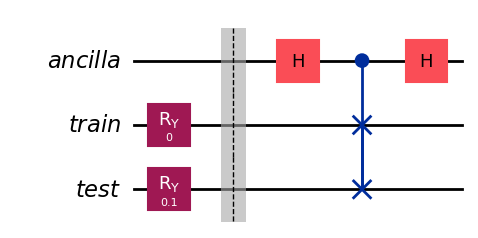

Fidelity(Test 0, Train 0 [Class A]): 0.9976
Fidelity(Test 0, Train 1 [Class B]): 0.0018
Top 1 Neighbors: ['Class A']
Final Prediction for Test Point 0: Class A


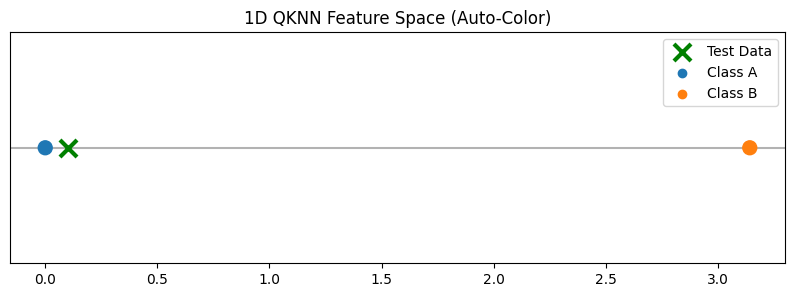

In [61]:
def visualize_2d(train_data, train_labels, test_data):
    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {label: cm(i) for i, label in enumerate(unique_labels)}
    
    plt.figure(figsize=(8, 6))
    
    train_x, train_y = zip(*train_data)
    test_x, test_y = zip(*test_data)
    
    plt.scatter(train_x, train_y, 
                c=[color_map[l] for l in train_labels], s=100, zorder=2)
    
    plt.scatter(test_x, test_y, 
                c='green', marker='x', s=150, linewidths=3, label='Test Data', zorder=3)
    
    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label)
    
    plt.title("2D QKNN Feature Space (Auto-Color)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

def compute_fidelity(train_point, test_point, show_circuit):
    no_dimensions = len(train_point)
    ancilla = QuantumRegister(1, name="ancilla")
    reg_a = QuantumRegister(no_dimensions, name="train")
    reg_b = QuantumRegister(no_dimensions, name="test")
    qc = QuantumCircuit(ancilla, reg_a, reg_b)

    # 1. Encoding
    for i in range(no_dimensions):
        qc.ry(train_point[i], reg_a[i])
        qc.ry(test_point[i], reg_b[i])
    qc.barrier()

    # 2. SWAP Test
    qc.h(ancilla)
    for i in range(no_dimensions):
        qc.cswap(ancilla[0], reg_a[i], reg_b[i])
    qc.h(ancilla)

    if show_circuit:
        display(qc.draw("mpl"))

    observable = SparsePauliOp("I" * (2 * no_dimensions) + "Z") # Measure q0
    isa_circuit = pm.run(qc)
    isa_observable = observable.apply_layout(isa_circuit.layout)
    estimator = Estimator(backend)
    job = estimator.run([(isa_circuit, isa_observable)], precision=0.01)
    result = job.result()[0].data.evs
    
    return float(result)

def qknn(train_data, train_labels, test_data, K):
    backend = FakeBelemV2()
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    show_circuit = True

    for i, test_pt in enumerate(test_data):
        fidelities = []
        
        for j, train_pt in enumerate(train_data):
            fid = compute_fidelity(train_pt, test_pt, show_circuit)
            show_circuit = False
            fidelities.append((fid, train_labels[j]))
            print(f"Fidelity(Test {i}, Train {j} [{train_labels[j]}]): {fid:.4f}")

        fidelities.sort(key=lambda x: x[0], reverse=True)
        
        top_k_labels = [label for fid, label in fidelities[:K]]
        
        vote_counts = Counter(top_k_labels)
        prediction = vote_counts.most_common(1)[0][0]
        
        print(f"Top {K} Neighbors: {top_k_labels}")
        print(f"Final Prediction for Test Point {i}: {prediction}")
    
    no_dimensions = len(train_data[0])
    if no_dimensions == 1:
        visualize_1d(train_data, train_labels, test_data)
    elif no_dimensions == 2:
        visualize_2d(train_data, train_labels, test_data)

K = 1 # Number of nearest neighbors to consider

train_data = [np.array([0.0]), np.array([np.pi])] 
train_labels = ["Class A", "Class B"]
test_data = [np.array([0.1])]

qknn(train_data, train_labels, test_data, K)

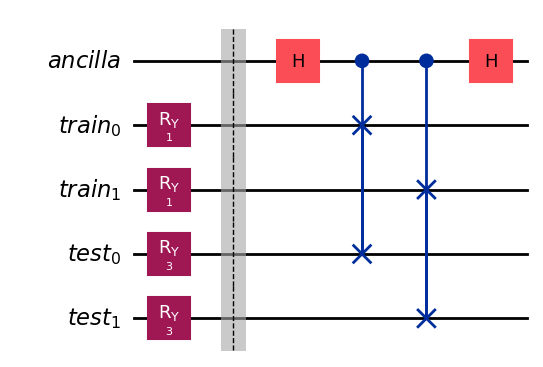

Fidelity(Test 0, Train 0 [Class A]): 0.0982
Fidelity(Test 0, Train 1 [Class A]): 0.7716
Fidelity(Test 0, Train 2 [Class B]): 0.5916
Fidelity(Test 0, Train 3 [Class B]): 0.0868
Top 1 Neighbors: ['Class A']
Final Prediction for Test Point 0: Class A
Fidelity(Test 1, Train 0 [Class A]): -0.0104
Fidelity(Test 1, Train 1 [Class A]): 0.3104
Fidelity(Test 1, Train 2 [Class B]): 0.7766
Fidelity(Test 1, Train 3 [Class B]): 0.2312
Top 1 Neighbors: ['Class B']
Final Prediction for Test Point 1: Class B


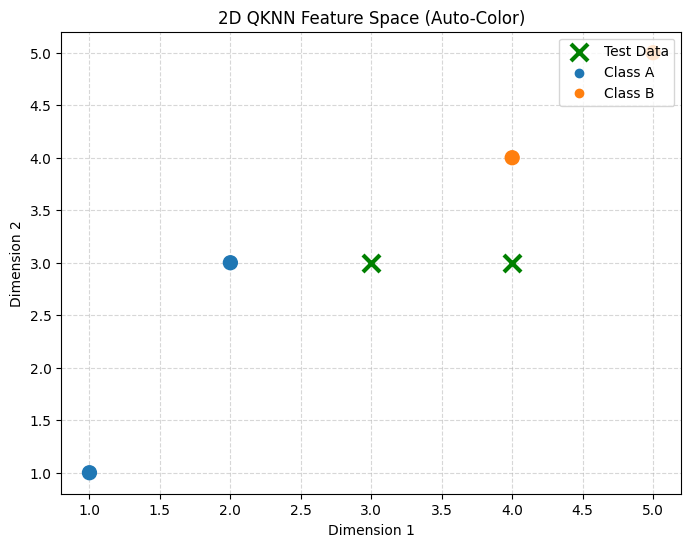

In [62]:
K = 1

train_data_2d = [
    np.array([1, 1]),
    np.array([2, 3]),
    np.array([4, 4]),
    np.array([5, 5])
]
train_labels_2d = ["Class A", "Class A", "Class B", "Class B"]

test_data_2d = [np.array([3, 3]), np.array([4, 3])]

qknn(train_data_2d, train_labels_2d, test_data_2d, K)